# Static Dashboard — Energy Poverty Prediction

This dashboard communicates the key findings from the Energy Poverty Prediction project.
It uses World Bank data (1990–2023) across 218 countries to model and visualise
electricity access patterns, risk categories, and 2024–2027 forecasts.

## Key Takeaways
1. Global average electricity access rose from ~72% (1990) to ~90% (2023) but
   ~700M people remain without access — concentrated in Sub-Saharan Africa.
2. GDP per capita and renewable energy are the strongest predictors of electricity access.
3. RF Baseline classifier achieved **92.97% validation accuracy** predicting risk category.
4. RF Improved regressor achieved **R²=0.9178** predicting exact electricity access %.
5. **27 countries** are still projected to be in Severe energy poverty risk by 2027.

## Dashboard Structure
- **View 1**   — Global electricity access trend (1990–2023)
- **View 2**   — Risk category distribution over time
- **View 3**   — Electricity Access Progress (1990–2023)
- **View 4**   — Feature importance (what drives predictions)
- **View 5**   — Correlation with Electricity Access
- **View 6**   — Model performance comparison
- **View 7**   — Test set evaluation (actual vs predicted)
- **View 8**   — GDP vs electricity access relationship
- **View 9**   — 2024–2027 forecast
- **Widget A** — Country explorer (dropdown)
- **Widget B** — Year snapshot (slider)
- **Widget C** — Region comparison (multi-select)

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    WIDGETS = True
    print("✓ ipywidgets available — interactive widgets enabled")
except ImportError:
    WIDGETS = False
    print("ipywidgets not available — static fallbacks will be used")

# Load all data 
df          = pd.read_csv("data/processed/analysis_ready.csv")
test_df     = pd.read_csv("data/processed/test_predictions.csv")
feat_imp    = pd.read_csv("data/processed/feature_importance.csv")
forecast_df = pd.read_csv("data/processed/forecast_2024_2027.csv")

print(f"\n analysis_ready    : {df.shape}")
print(f" test_predictions  : {test_df.shape}")
print(f" feature_importance: {feat_imp.shape}")
print(f" forecast_2024_2027: {forecast_df.shape}")

✓ ipywidgets available — interactive widgets enabled

 analysis_ready    : (7412, 15)
 test_predictions  : (654, 7)
 feature_importance: (20, 3)
 forecast_2024_2027: (872, 16)



## View 1 — Global Electricity Access Trend (1990–2023)

How has global electricity access changed over 34 years?
 - Left chart shows the global average rising from ~72% (1990) to ~90% (2023)
 - Right chart shows the distribution across countries in the most recent year
 - The bimodal shape on the right reveals deep inequality — many countries near 100%, many still stuck below 50%

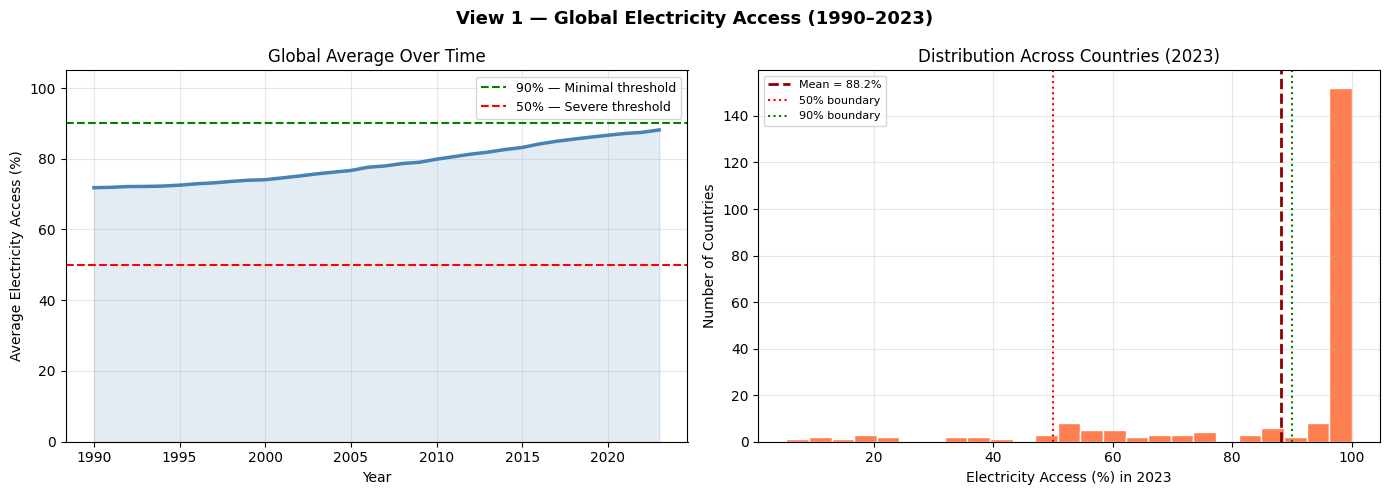

In [2]:
# View 1: Global Electricity Access (1990–2023) 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("View 1 — Global Electricity Access (1990–2023)",
             fontsize=13, fontweight='bold')

# Left: global average over time
global_avg = df.groupby('year')['electricity_access'].mean()
axes[0].plot(global_avg.index, global_avg.values,
             color='steelblue', linewidth=2.5)
axes[0].fill_between(global_avg.index, global_avg.values,
                     alpha=0.15, color='steelblue')
axes[0].axhline(90, color='green', linestyle='--',
                linewidth=1.5, label='90% — Minimal threshold')
axes[0].axhline(50, color='red', linestyle='--',
                linewidth=1.5, label='50% — Severe threshold')
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average Electricity Access (%)")
axes[0].set_title("Global Average Over Time")
axes[0].set_ylim(0, 105)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: distribution in most recent year
latest    = int(df['year'].max())
latest_df = df[df['year'] == latest]['electricity_access'].dropna()
axes[1].hist(latest_df, bins=25, color='coral', edgecolor='white')
axes[1].axvline(latest_df.mean(), color='darkred', linestyle='--',
                linewidth=2, label=f"Mean = {latest_df.mean():.1f}%")
axes[1].axvline(50, color='red', linestyle=':',
                linewidth=1.5, label='50% boundary')
axes[1].axvline(90, color='green', linestyle=':',
                linewidth=1.5, label='90% boundary')
axes[1].set_xlabel(f"Electricity Access (%) in {latest}")
axes[1].set_ylabel("Number of Countries")
axes[1].set_title(f"Distribution Across Countries ({latest})")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## View 2 — Risk Category Distribution (1990–2023)

How are countries distributed across risk categories and how has this changed over time?

- **Left:** Overall count of country-year rows in each risk category across the full dataset.
  Minimal dominates at 4,614 rows — most countries have had good access for many years.
- **Right:** How the number of countries in each category changed year by year.
  Severe (red) has declined steadily since 1990 — global progress is real.
  The dashed lines mark the train/validation/test split boundaries.

**Key insight:** The sharp drop in Severe countries after 2010 reflects major
electrification pushes in South Asia and Sub-Saharan Africa.

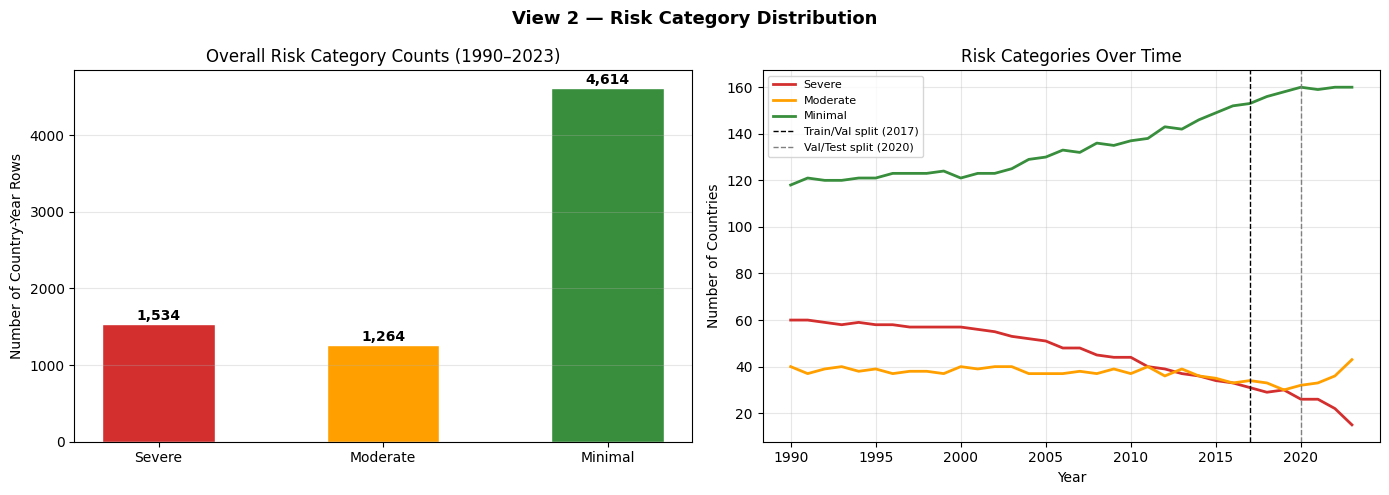

In [3]:
# View 2: Risk Category Distribution — Bar Charts + Line Plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("View 2 — Risk Category Distribution",
             fontsize=13, fontweight='bold')

order  = ['Severe', 'Moderate', 'Minimal']
colors = ['#D32F2F', '#FFA000', '#388E3C']

# Left: overall counts
counts = df['risk_category'].value_counts()
vals   = [counts.get(c, 0) for c in order]
bars   = axes[0].bar(order, vals, color=colors,
                     edgecolor='white', width=0.5)
axes[0].set_title("Overall Risk Category Counts (1990–2023)")
axes[0].set_ylabel("Number of Country-Year Rows")
axes[0].grid(True, axis='y', alpha=0.3)
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{v:,}', ha='center', fontweight='bold')

# Right: trend over time with split boundaries
risk_by_year = (df.groupby(['year', 'risk_category'])
                .size().unstack(fill_value=0))
for cat, col in zip(order, colors):
    if cat in risk_by_year.columns:
        axes[1].plot(risk_by_year.index, risk_by_year[cat],
                     label=cat, color=col, linewidth=2)

axes[1].axvline(2017, color='black', linestyle='--',
                linewidth=1, label='Train/Val split (2017)')
axes[1].axvline(2020, color='grey', linestyle='--',
                linewidth=1, label='Val/Test split (2020)')
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of Countries")
axes[1].set_title("Risk Categories Over Time")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## View 3 — Electricity Access Progress (1990–2023)

Which countries improved the most and which are still the worst off?
 - Left chart shows the top 10 most improved countries by percentage point gain
 - Right chart shows the 15 countries with the lowest electricity access today
 - Dark red bars = below 30% access — the most critical cases requiring intervention

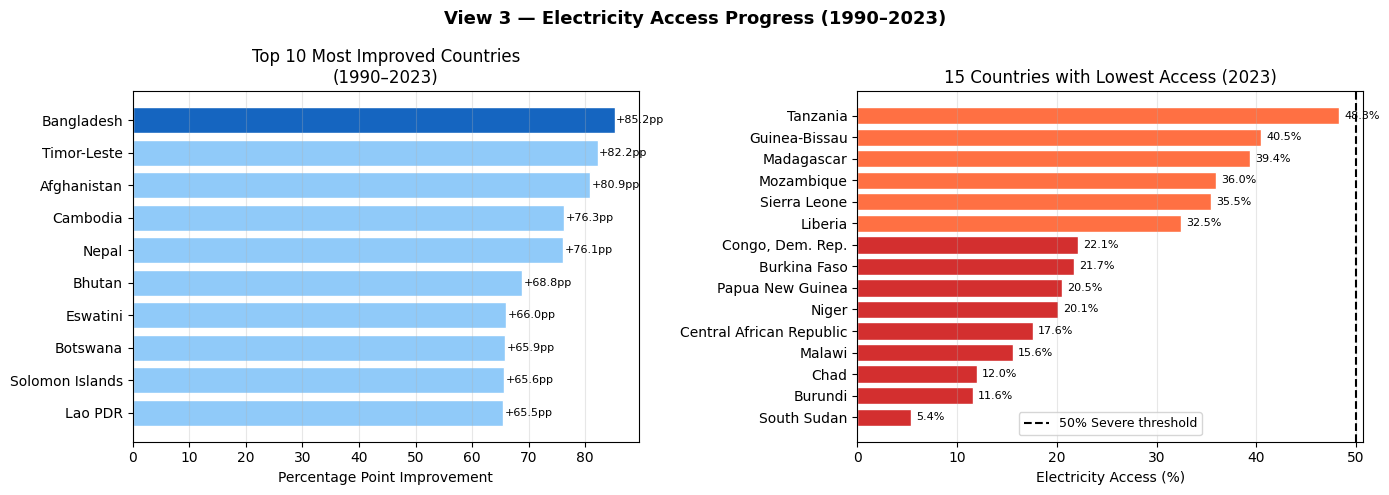

In [4]:
# View 3: Progress & Challenges — Bar Charts

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("View 3 — Electricity Access Progress (1990–2023)",
             fontsize=13, fontweight='bold')

# Left: top 10 most improved countries
first_year = df.groupby('country')['electricity_access'].first()
last_year  = df.groupby('country')['electricity_access'].last()
improvement = (last_year - first_year).sort_values(ascending=False).head(10)

colors_imp = ['#1565C0' if i == 0 else '#90CAF9' for i in range(len(improvement))]
axes[0].barh(improvement.index[::-1], improvement.values[::-1],
             color=colors_imp[::-1], edgecolor='white')
axes[0].set_xlabel("Percentage Point Improvement")
axes[0].set_title("Top 10 Most Improved Countries\n(1990–2023)")
axes[0].grid(True, axis='x', alpha=0.3)
for i, (country, val) in enumerate(zip(improvement.index[::-1], improvement.values[::-1])):
    axes[0].text(val + 0.3, i, f'+{val:.1f}pp', va='center', fontsize=8)

# Right: countries still below 50% in most recent year
latest_year = int(df['year'].max())
severe_now  = (df[df['year'] == latest_year]
               .sort_values('electricity_access')
               .head(15)[['country', 'electricity_access']])
colors_sev  = ['#D32F2F' if v < 30 else '#FF7043'
               for v in severe_now['electricity_access']]
axes[1].barh(severe_now['country'], severe_now['electricity_access'],
             color=colors_sev, edgecolor='white')
axes[1].axvline(50, color='black', linestyle='--',
                linewidth=1.5, label='50% Severe threshold')
axes[1].set_xlabel("Electricity Access (%)")
axes[1].set_title(f"15 Countries with Lowest Access ({latest_year})")
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='x', alpha=0.3)
for i, (_, row) in enumerate(severe_now.iterrows()):
    axes[1].text(row['electricity_access'] + 0.5, i,
                 f"{row['electricity_access']:.1f}%", va='center', fontsize=8)

plt.tight_layout()
plt.show()

## View 4 — Feature Importance — Best Models

Which features contributed most to each model's predictions?
The **dark blue bar** is the single most important feature in each model.

- **Left (Regressor):** `renewable_energy_percent` dominates at 0.445 — a country's
  energy mix is the strongest signal for predicting exact electricity access %.
  `gdp_per_capita` is second at 0.231 — economic wealth drives infrastructure investment.

- **Right (Classifier):** More balanced distribution — `renewable_energy_percent` (0.227)
  and `gdp_per_capita` (0.186) lead, but population and urbanisation features also
  contribute meaningfully to classifying risk category.

**Key insight:** Both models agree that energy mix and economic output are the
primary drivers of electricity access — policy interventions targeting renewable
investment and economic development will have the most impact on reducing energy poverty.

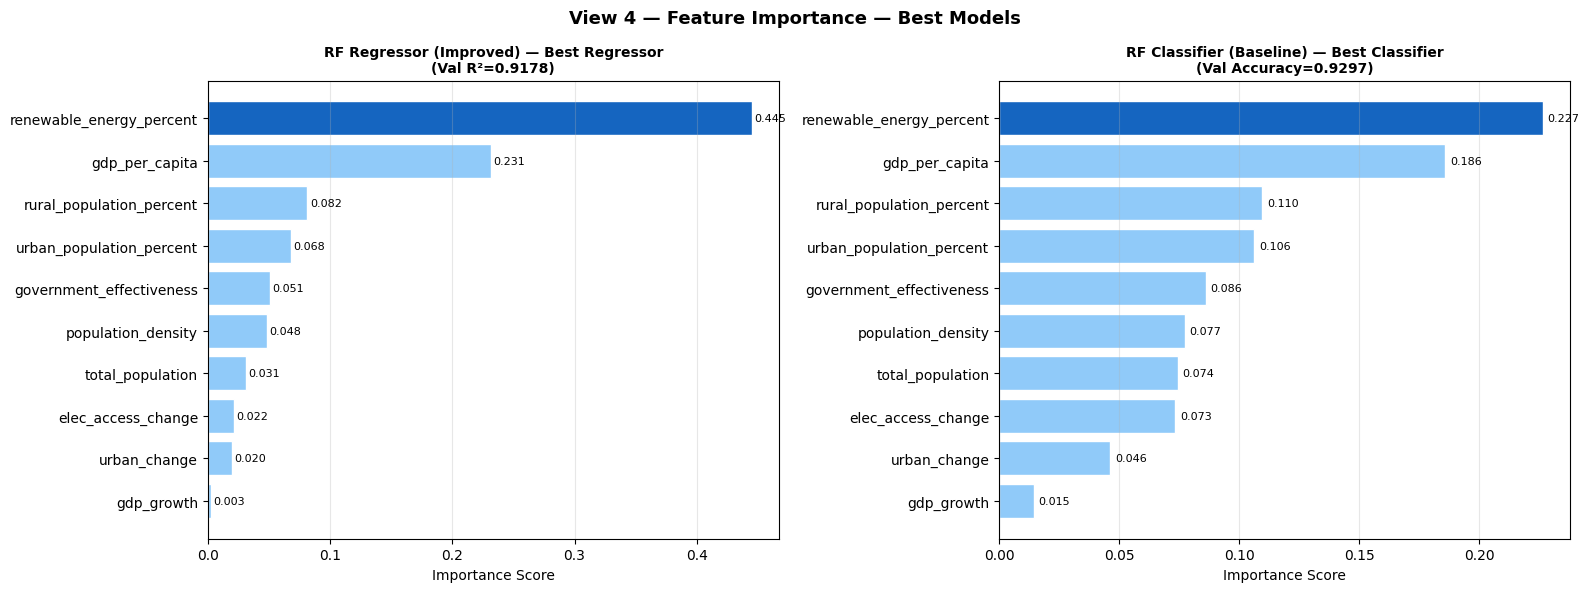

In [5]:
# View 4: Feature Importance — Bar Charts

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("View 4 — Feature Importance — Best Models",
             fontsize=13, fontweight='bold')

cls_imp = feat_imp[feat_imp['model'] == 'classifier'].sort_values('importance')
reg_imp = feat_imp[feat_imp['model'] == 'regressor'].sort_values('importance')

for ax, imp, title in zip(
    axes,
    [reg_imp, cls_imp],
    ['RF Regressor (Improved) — Best Regressor\n(Val R²=0.9178)',
     'RF Classifier (Baseline) — Best Classifier\n(Val Accuracy=0.9297)']
):
    colors_bar = ['#1565C0' if v == imp['importance'].max()
                  else '#90CAF9' for v in imp['importance']]
    ax.barh(imp['feature'], imp['importance'],
            color=colors_bar, edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Importance Score')
    ax.grid(True, axis='x', alpha=0.3)
    for i, (feat, val) in enumerate(zip(imp['feature'], imp['importance'])):
        ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## View 5 — Correlation with Electricity Access

Pearson correlation of each feature against the target variable `electricity_access`.

- **Blue bars** = positive correlation — higher value means higher electricity access
- **Red bars** = negative correlation — higher value means lower electricity access

**Key findings:**
- `rural_population_percent` is the strongest negative driver — more rural population
  means less electricity access, reflecting the high cost of extending grids to
  remote areas
- `gdp_per_capita` and `renewable_energy_percent` are the strongest positive drivers —
  confirming that economic wealth and clean energy investment go hand in hand with
  electrification
- `government_effectiveness` has a moderate positive correlation — stronger institutions
  are better at delivering infrastructure to their populations
- `gdp_growth` and `urban_change` show near-zero correlation — annual change rates
  matter less than the underlying structural levels

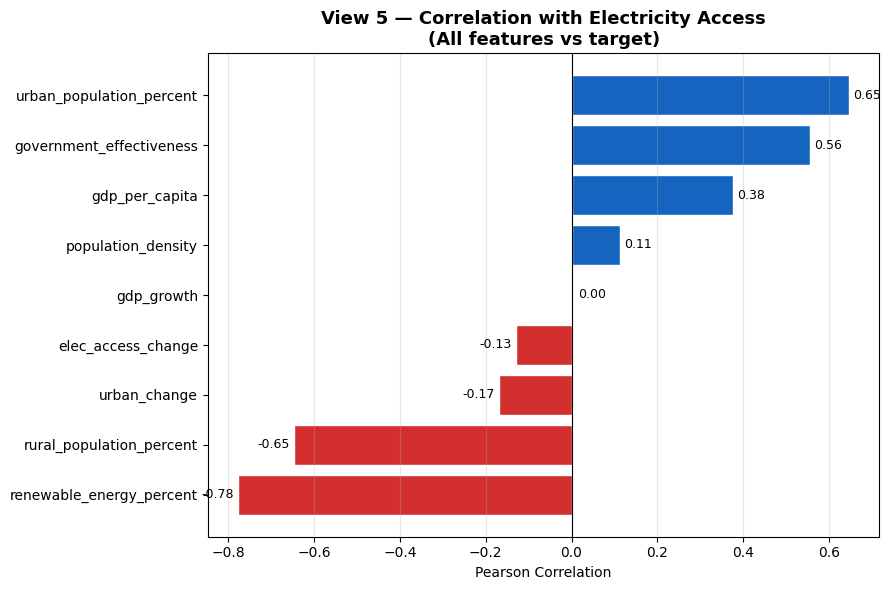

In [6]:
# View 5 — Correlation with Electricity Access
numeric_cols = ['electricity_access', 'gdp_per_capita', 'urban_population_percent',
                'rural_population_percent', 'renewable_energy_percent',
                'government_effectiveness', 'population_density',
                'elec_access_change', 'gdp_growth', 'urban_change']

corr = (df[numeric_cols].corr()['electricity_access']
        .drop('electricity_access')
        .sort_values())

colors_corr = ['#D32F2F' if v < 0 else '#1565C0' for v in corr.values]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(corr.index, corr.values, color=colors_corr, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("View 5 — Correlation with Electricity Access\n(All features vs target)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Pearson Correlation")
ax.grid(True, axis='x', alpha=0.3)

for i, (feat, val) in enumerate(zip(corr.index, corr.values)):
    offset = 0.01 if val >= 0 else -0.01
    ha     = 'left' if val >= 0 else 'right'
    ax.text(val + offset, i, f'{val:.2f}', va='center', fontsize=9, ha=ha)

plt.tight_layout()
plt.show()